In [ ]:
import pandas as pd
import numpy as np
#data cleaning
df = pd.read_csv('https://raw.githubusercontent.com/veghmark12/dataviz/main/data.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
to_drop = ['AcF','AR','AS']
df.drop(to_drop, inplace=True, axis=1)
nan_value = float("NaN")
df.replace("Kód", nan_value, inplace=True)
df.replace("#DIV/0!", 'NaN', inplace=True)
# to_drop2 = ['4','6','24','0.25','0.5','0.75','1','1.25','1.5','1.75']
# df.replace(to_drop2, nan_value, inplace=True)
df.dropna(subset = ['kod','konverzio','ido'],inplace = True, axis=0)

In [ ]:
df[['koncentracio', 'oldoszer']] = df['kozeg'].str.split(' ', n=1, expand=True)
df.drop(['kozeg'], inplace = True, axis = 1)
df[['konc', 'valami']] = df['koncentracio'].str.split('%', n=1, expand=True)
df.drop(['valami','koncentracio'], inplace = True, axis = 1)


df.replace(["8","6","4","24",'0.25','0.5','0.75','1','1.25','1.5','1.75'], nan_value, inplace=True)
df.replace(["HEPES","DMSO"], nan_value, inplace=True)
df.dropna(subset = ['konc','oldoszer','ido'],inplace = True, axis=0)
df

,kod,ido,konverzio,oldoszer,konc
4,613,2,49.12180797,glycerol,10
5,614,2,49.7890854,glycerol,20
6,615,2,49.6711717,glycerol,30
7,616,2,10.11434917,IPA,10
8,617,2,1.403365121,IPA,20
...,...,...,...,...,...
507,736,2,50,2-OH-propil-ciklodextrin,50mM
508,737,2,50,glucose,50mM
509,738,2,50,maltose,50mM
510,739,2,50,trehalose,50mM


In [ ]:
df['konc'].replace(['2.5mM','5mM','10mM','25mM','50mM'], nan_value, inplace=True)
df.dropna(subset = ['konc'],inplace = True, axis=0)
df

,kod,ido,konverzio,oldoszer,konc
4,613,2,49.12180797,glycerol,10
5,614,2,49.7890854,glycerol,20
6,615,2,49.6711717,glycerol,30
7,616,2,10.11434917,IPA,10
8,617,2,1.403365121,IPA,20
9,618,2,0.995028984,IPA,30
61,640,2,49.87770387,TWEEN 80,10
62,641,2,49.90482066,TWEEN 80,20
63,642,2,49.83313133,TWEEN 80,5
124,653,2,0.566139337,lactic acid+β-alanin,10


In [ ]:
df['konc'] = df['konc'].astype(int)
df = df.sort_values(by=['oldoszer', 'konc'])
df

,kod,ido,konverzio,oldoszer,konc
329,692,2,20.13426217,"1,5-pentanediol",10
330,693,2,6.070363395,"1,5-pentanediol",20
331,694,2,2.219286429,"1,5-pentanediol",30
127,656,2,0.584027823,ChCl-glycerol,10
128,657,2,0.486318737,ChCl-glycerol,20
129,658,2,0.415428288,ChCl-glycerol,30
130,659,2,0.4420173,ChCl-lactic acid,10
131,660,2,0.343988523,ChCl-lactic acid,20
132,661,2,0.396335862,ChCl-lactic acid,30
272,685,2,9.140001728,DMF,10


In [ ]:
unique_count_solvents = df['oldoszer'].unique()
unique_count_konc = df['konc'].unique()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data: solvents and their relative activities at different concentrations

concentrations = ['5','10','25']

# konverziok szerinti csokkeno sorrend
oldoszer=list(df['oldoszer'])
konverziok = list(df['konverzio'])
konc = list(df['konc'])

In [ ]:
numpy_array1 = np.array(list(map(str, oldoszer)))
numpy_array2 = np.array(list(map(float, konverziok)))
numpy_array3 = np.array(list(map(float, konc)))

In [ ]:
reshaped_array = numpy_array2.reshape(-1, 3)

In [ ]:
averages = np.nanmean(reshaped_array, axis=1)
sorted_indices_descending = np.argsort(averages)[::-1]
sorted_array_of_arrays_descending = reshaped_array[sorted_indices_descending]
sorted_array_of_arrays_descending

array([[49.83313133, 49.87770387, 49.90482066],
       [49.12180797, 49.7890854 , 49.6711717 ],
       [49.4095275 , 48.35995868, 47.31464221],
       [49.52577589, 46.13881283, 33.04527964],
       [35.88162816,  9.97558708,  2.22212006],
       [20.13426217,  6.0703634 ,  2.21928643],
       [21.4925522 ,  3.80353455,  0.71256548],
       [16.54113085,  2.43843812,  0.97028706],
       [10.11434917,  1.40336512,  0.99502898],
       [ 9.14000173,  1.83127125,  1.0282668 ],
       [ 6.99374283,  1.89114391,  1.02539924],
       [ 1.15017118,  1.12156724,  1.47041115],
       [ 0.6200531 ,  0.75803704,  0.76032601],
       [ 0.58402782,  0.48631874,  0.41542829],
       [ 0.56613934,  0.3954752 ,  0.42247603],
       [ 0.4420173 ,  0.34398852,  0.39633586]])

In [ ]:
solvents0 = np.unique(numpy_array1)
solvents = solvents0[sorted_indices_descending]
solvents = solvents[8:16]

activities = sorted_array_of_arrays_descending
activities = activities[8:16]
specific_value = 46.27

activities4 = np.array([[46.27, 30.83, 7.15],[46.27, 30.83, 7.15],[46.27, 30.83, 7.15],[46.27, 30.83, 7.15],[46.27, 30.83, 7.15],[46.27, 30.83, 7.15],[46.27, 30.83, 7.15],[46.27, 30.83, 7.15]])

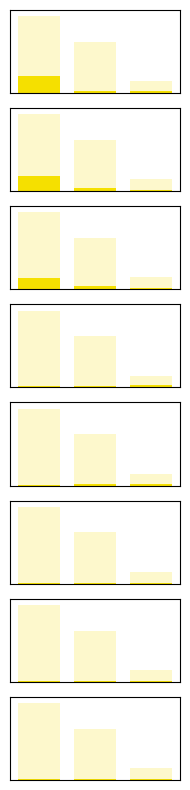

In [ ]:
# Create bar plots for each solvent in the first column
fig, axs = plt.subplots(len(solvents), figsize=(2,8), sharex=True)
fig.patch.set_facecolor('#FFFFFF')

for i in range(len(solvents)):
    axs[i].bar(concentrations,
                activities[i],
                color='#F5E000',
                width=0.75,
                alpha=1)
    axs[i].bar(concentrations,
                activities4[i],
                color='#F5E000',
                width=0.75,
                alpha=0.2)
    #axs[i].set_ylabel(solvents[i], rotation=0,labelpad=75)
    axs[i].yaxis.tick_right()
    axs[i].set_yticks([])
    axs[i].set_ylim(0, 50)
    axs[i].set_facecolor('#FFFFFF')
    #axs[i].axhline(specific_value, color='black', linewidth=0.5)

plt.yticks([])
plt.xticks([])
plt.tight_layout()
plt.savefig("16folyadek.png", format="png", dpi=1200)
plt.show()

In [ ]:
activities

array([[10.11434917,  1.40336512,  0.99502898],
       [ 9.14000173,  1.83127125,  1.0282668 ],
       [ 6.99374283,  1.89114391,  1.02539924],
       [ 1.15017118,  1.12156724,  1.47041115],
       [ 0.6200531 ,  0.75803704,  0.76032601],
       [ 0.58402782,  0.48631874,  0.41542829],
       [ 0.56613934,  0.3954752 ,  0.42247603],
       [ 0.4420173 ,  0.34398852,  0.39633586]])